<a href="https://colab.research.google.com/github/Its-leila/fdi-analysis/blob/main/fdi_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FDI, Economic Growth, Inflation, and Exchange Rate Volatility
### A Regression Analysis of Iran and Regional Economies

**Author:** Leila Rezaei  
**Research interests:** Applied economics, international business

---

## Research Question
Do GDP growth, inflation, and exchange rate volatility significantly affect Foreign Direct Investment (FDI) net inflows in Iran, compared to regional peer economies (Turkey, Saudi Arabia, UAE)?

## Hypothesis
H1: Higher exchange rate volatility is associated with lower FDI inflows (as % of GDP).  
H2: Higher GDP growth is associated with higher FDI inflows.  
H3: Higher inflation is associated with lower FDI inflows.

## Data Source
World Bank World Development Indicators (WDI), accessed via the `wbdata` Python package, 2000–2023.

## Method
Pooled OLS regression with country fixed effects, using `statsmodels`.

## 1. Setup
Run this cell first. If you are in Google Colab, this installs the one package that isn't pre-installed (`wbdata`).

In [ ]:
!pip install wbdata -q

In [ ]:
import pandas as pd
import numpy as np
import wbdata
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

## 2. Fetch Data from the World Bank API

Indicators used:
- `BX.KLT.DINV.WD.GD.ZS` — FDI, net inflows (% of GDP)
- `NY.GDP.MKTP.KD.ZG` — GDP growth (annual %)
- `FP.CPI.TOTL.ZG` — Inflation, consumer prices (annual %)
- `PA.NUS.FCRF` — Official exchange rate (LCU per US$, period average)

Countries: Iran (IRN), Turkey (TUR), Saudi Arabia (SAU), United Arab Emirates (ARE).

In [3]:
indicators = {
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_pct_gdp',
    'NY.GDP.MKTP.KD.ZG': 'gdp_growth',
    'FP.CPI.TOTL.ZG': 'inflation',
    'PA.NUS.FCRF': 'exchange_rate'
}

countries = ['IRN', 'TUR', 'SAU', 'ARE']

raw = wbdata.get_dataframe(indicators, country=countries, date=('2000', '2023'))
raw = raw.reset_index()
raw.head()

,country,date,fdi_pct_gdp,gdp_growth,inflation,exchange_rate
0,United Arab Emirates,2023,5.871840,4.301136,1.626708,3.6725
1,United Arab Emirates,2022,4.445914,7.514524,5.291226,3.6725
2,United Arab Emirates,2021,4.892306,4.552801,0.179935,3.6725
3,United Arab Emirates,2020,5.567357,-8.693434,-2.079403,3.6725
4,United Arab Emirates,2019,4.119286,1.271291,-1.931081,3.6725


## 3. Clean the Data

In [4]:
df = raw.rename(columns={'country': 'country'}).copy()
df['date'] = df['date'].astype(int)
df = df.sort_values(['country', 'date']).reset_index(drop=True)

# Year-over-year % change in the exchange rate = our volatility proxy
df['fx_change'] = df.groupby('country')['exchange_rate'].pct_change() * 100

# Drop rows with missing values in the variables we need for the model
model_df = df.dropna(subset=['fdi_pct_gdp', 'gdp_growth', 'inflation', 'fx_change']).copy()

print(f'Rows before cleaning: {len(df)}')
print(f'Rows after cleaning:  {len(model_df)}')
model_df.head()

Rows before cleaning: 96
Rows after cleaning:  85


,country,date,fdi_pct_gdp,gdp_growth,inflation,exchange_rate,fx_change
1,"Iran, Islamic Rep.",2001,0.321660,2.392173,11.274247,1753.985685,-0.615936
2,"Iran, Islamic Rep.",2002,2.736115,8.078829,14.335934,6907.034456,293.790811
3,"Iran, Islamic Rep.",2003,1.894186,8.639298,16.468012,8193.887519,18.631050
4,"Iran, Islamic Rep.",2004,1.617697,4.336666,14.761509,8613.989421,5.127016
5,"Iran, Islamic Rep.",2005,1.284254,3.189804,13.433118,8963.958907,4.062804


## 4. Exploratory Data Analysis

In [5]:
model_df.groupby('country')[['fdi_pct_gdp', 'gdp_growth', 'inflation', 'fx_change']].describe().T

country            Iran, Islamic Rep.  Saudi Arabia    Turkiye  \
fdi_pct_gdp count           23.000000     23.000000  23.000000   
            mean             0.800925      0.891163   1.579306   
            std              0.582907      0.966964   0.764571   
            min              0.310885     -0.323900   0.449377   
            25%              0.466573      0.164256   1.194052   
            50%              0.609502      0.669626   1.488396   
            75%              0.810864      1.427018   1.787333   
            max              2.736115      3.185186   3.606602   
gdp_growth  count           23.000000     23.000000  23.000000   
            mean             3.120669      3.952490   5.098680   
            std              3.800311      3.966213   4.351529   
            min             -3.747960     -3.804789  -5.459408   
            25%              0.629121      1.416848   3.395909   
            50%              4.130897      3.313485   5.441225   
            75%              5.166073      6.091442   8.157057   
            max              8.815087     12.000587  11.811094   
inflation   count           23.000000     23.000000  23.000000   
            mean            21.790794      2.468407  18.661458   
            std             12.340307      2.536323  18.622424   
            min              7.245425     -1.192986   6.250977   
            25%             12.958900      0.563852   8.372802   
            50%             16.606553      2.327085   9.597242   
            75%             28.925476      3.441696  17.964478   
            max             44.579186      9.870248  72.308836   
fx_change   count           23.000000     23.000000  23.000000   
            mean            21.593196      0.000000  19.440468   
            std             60.799742      0.000000  26.322914   
            min             -0.615936      0.000000  -8.787301   
            25%              1.394815      0.000000   2.946123   
            50%              4.062804      0.000000  14.958448   
            75%             13.260401      0.000000  23.904688   
            max            293.790811      0.000000  96.025563   

country            United Arab Emirates  
fdi_pct_gdp count             16.000000  
            mean               3.053140  
            std                1.496541  
            min                0.447367  
            25%                2.327622  
            50%                2.541581  
            75%                4.200943  
            max                5.871840  
gdp_growth  count             16.000000  
            mean               2.668162  
            std                4.456698  
            min               -8.693434  
            25%                1.470728  
            50%                4.426969  
            75%                5.103313  
            max                7.514524  
inflation   count             16.000000  
            mean               2.092970  
            std                3.289526  
            min               -2.079403  
            25%                0.823577  
            50%                1.589651  
            75%                2.526860  
            max               12.250420  
fx_change   count             16.000000  
            mean               0.000000  
            std                0.000000  
            min                0.000000  
            25%                0.000000  
            50%                0.000000  
            75%                0.000000  
            max                0.000000

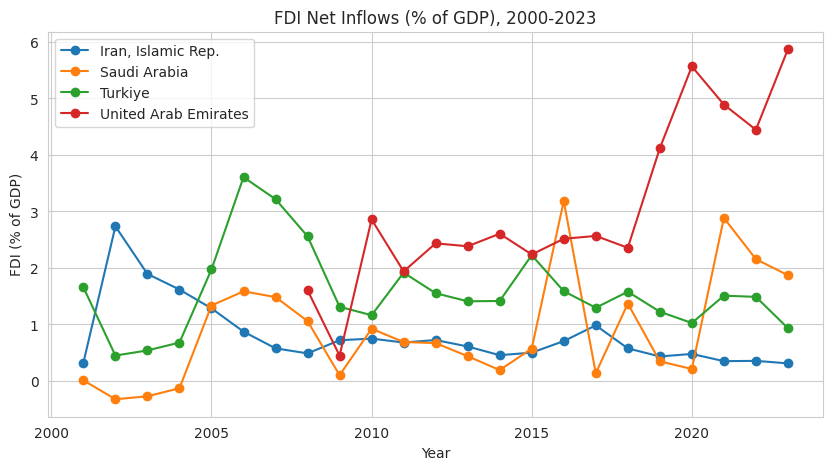

In [6]:
fig, ax = plt.subplots()
for c, sub in model_df.groupby('country'):
    ax.plot(sub['date'], sub['fdi_pct_gdp'], marker='o', label=c)
ax.set_title('FDI Net Inflows (% of GDP), 2000-2023')
ax.set_xlabel('Year')
ax.set_ylabel('FDI (% of GDP)')
ax.legend()
plt.show()

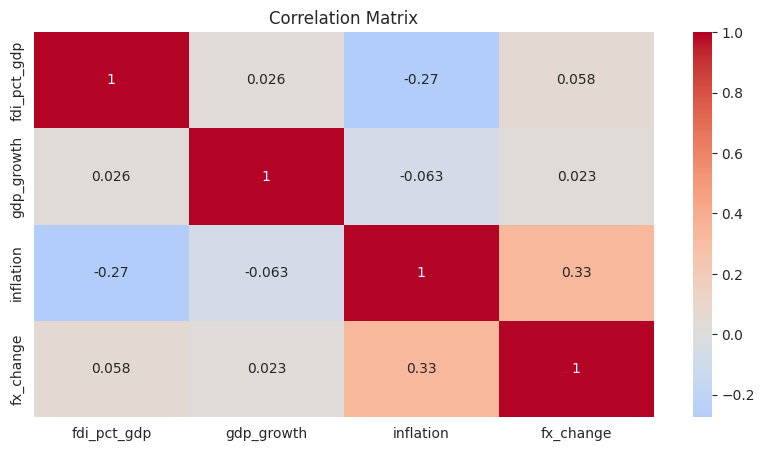

In [7]:
corr = model_df[['fdi_pct_gdp', 'gdp_growth', 'inflation', 'fx_change']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

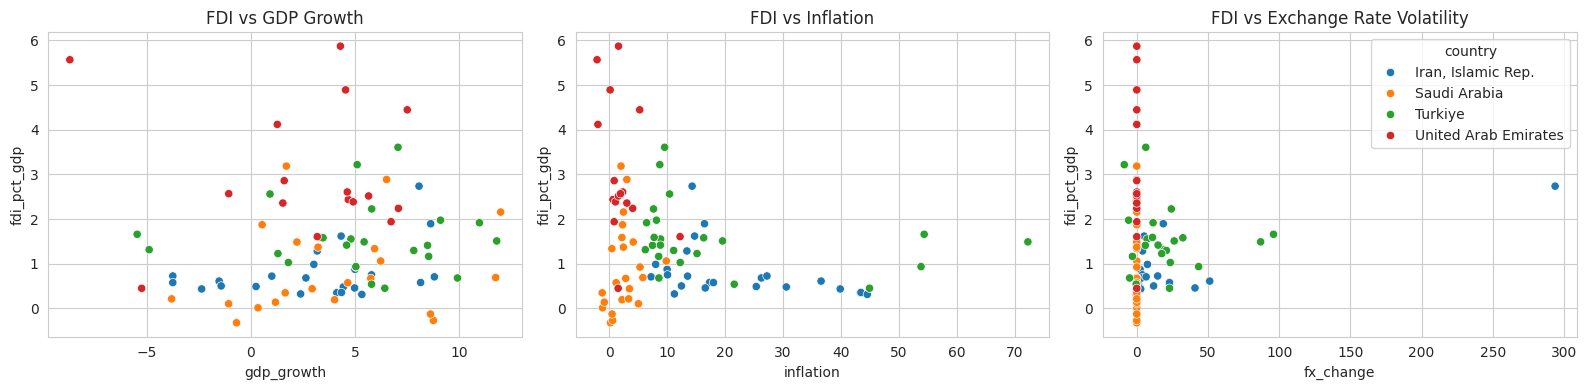

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.scatterplot(data=model_df, x='gdp_growth', y='fdi_pct_gdp', hue='country', ax=axes[0], legend=False)
axes[0].set_title('FDI vs GDP Growth')
sns.scatterplot(data=model_df, x='inflation', y='fdi_pct_gdp', hue='country', ax=axes[1], legend=False)
axes[1].set_title('FDI vs Inflation')
sns.scatterplot(data=model_df, x='fx_change', y='fdi_pct_gdp', hue='country', ax=axes[2])
axes[2].set_title('FDI vs Exchange Rate Volatility')
plt.tight_layout()
plt.show()

## 5. Regression Model

Pooled OLS with country fixed effects:

$$FDI_{it} = \beta_0 + \beta_1 GDPGrowth_{it} + \beta_2 Inflation_{it} + \beta_3 FXChange_{it} + \text{Country FE} + \varepsilon_{it}$$

In [9]:
model = smf.ols(
    'fdi_pct_gdp ~ gdp_growth + inflation + fx_change + C(country)',
    data=model_df
).fit(cov_type='HC3')  # robust standard errors

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            fdi_pct_gdp   R-squared:                       0.488
Model:                            OLS   Adj. R-squared:                  0.449
Method:                 Least Squares   F-statistic:                     46.15
Date:                Wed, 09 Sep 2026   Prob (F-statistic):           1.10e-23
Time:                        12:03:26   Log-Likelihood:                -111.11
No. Observations:                  85   AIC:                             236.2
Df Residuals:                      78   BIC:                             253.3
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

## 6. Interpretation

*(Fill this in after running the cells above with the real output.)*

- **GDP growth coefficient:** interpret sign and significance (p < 0.05?) — supports/rejects H2.
- **Inflation coefficient:** interpret sign and significance — supports/rejects H3.
- **Exchange rate volatility (`fx_change`) coefficient:** interpret sign and significance — supports/rejects H1.
- **R-squared:** how much variance in FDI is explained by the model.
- **Country fixed effects:** note whether Iran's baseline FDI differs significantly from the reference country.

## 7. Limitations

- Small sample (4 countries × ~20 years) limits statistical power.
- FDI is affected by many unobserved factors (sanctions, geopolitical events, oil prices) not captured here.
- World Bank data for Iran has gaps in some years due to reporting limitations.
- Correlation/regression here does not establish causation.

## 8. Save Cleaned Data

In [11]:
model_df.to_csv('wdi_fdi_data.csv', index=False)
print('Saved to wdi_fdi_data.csv')

Saved to wdi_fdi_data.csv
